# Synaptic Routing Architecture (SRA)
## 11: シナプスの動的削除（Hot-Swapの取り消し・特定ドメインのパージ）

このノートブックでは、SRAの機能である「シナプスの削除」を実証します。具体的には以下の2つのシナリオを検証します。
1. **プラグインの取り外し (`pop_synapses`)**: 後から追加（Hot-Swap）したシナプスを末尾から物理的に削除し、追加前の状態に復元します。
2. **特定ドメインのパージ (`clear_synapses`)**: 初期のベースモデルから特定の機能（例：Math）だけを抽出し、他と共用していないシナプスを安全に「ゼロクリア（空きスロット化）」します。

※ このノートブックはGPUがなくても実行可能です。

In [1]:
# 0. 環境セットアップ (Google Colab用)
import sys
import os

if 'google.colab' in sys.modules:
    if not os.path.exists('SynapticRouter'):
        !git clone https://github.com/JunSuzukiJapan/SynapticRouter.git
    %cd SynapticRouter
    !pip install tiktoken torch

# パスの追加
sys.path.append('.')
sys.path.append('./src')
if 'google.colab' not in sys.modules:
    sys.path.append('..')
    sys.path.append('../src')

from sra_language_models import MoESRALanguageModel
from sra_experiment import find_unshared_synapses
import torch
import tiktoken


### 1. プラグインの取り外し (`pop_synapses`)
まずは、小規模なモデルを構築し、動的にシナプスを追加した後、それを `pop_synapses` で取り外す動作を確認します。

In [2]:
# モデルの初期化
dim = 128
layers = 2
num_synapses = 4
k = 2
syn_hidden = 256
vocab_size = 1000

print("=== プラグインの取り外しデモ ===")
model = MoESRALanguageModel(vocab_size, dim, layers, num_synapses, k, syn_hidden)
print(f"[初期状態] 搭載シナプス数: {model.blocks[0].num_synapses}")
print(f"  ルーターの埋め込みテンソル形状: {model.blocks[0].router.get_full_emb().shape}")

# シナプスの追加 (Hot-Swap)
print("\nプラグインとしてシナプスを 2つ 追加します...")
model.add_synapses(2, freeze_base=True)
print(f"[追加後] 搭載シナプス数: {model.blocks[0].num_synapses}")
print(f"  ルーターの埋め込みテンソル形状: {model.blocks[0].router.get_full_emb().shape}")

# シナプスの取り外し (Undo Hot-Swap)
print("\n追加したシナプスを 1つ 取り外します...")
model.pop_synapses(1)
print(f"[取り外し後] 搭載シナプス数: {model.blocks[0].num_synapses}")
print(f"  ルーターの埋め込みテンソル形状: {model.blocks[0].router.get_full_emb().shape}")

=== プラグインの取り外しデモ ===
[初期状態] 搭載シナプス数: 4
  ルーターの埋め込みテンソル形状: torch.Size([4, 128])

プラグインとしてシナプスを 2つ 追加します...
[追加後] 搭載シナプス数: 6
  ルーターの埋め込みテンソル形状: torch.Size([6, 128])

追加したシナプスを 1つ 取り外します...
[取り外し後] 搭載シナプス数: 5
  ルーターの埋め込みテンソル形状: torch.Size([5, 128])


このように、`pop_synapses(N)` を呼び出すことで、末尾からN個のシナプステンソルが物理的に削除され、モデルの容量を復元できます。

### 2. 特定ドメインのパージ (`clear_synapses` と `find_unshared_synapses`)
次に、複数ドメインを学習したベースモデルの中から、「特定のドメイン（ここでは仮に `math`）でしか使われていない不要なシナプス」を自動検出し、ゼロクリアによって安全に無効化するプロセスを実証します。

In [3]:
import random
tokenizer = tiktoken.get_encoding("cl100k_base")
vocab_size = tokenizer.n_vocab

device = "cuda" if torch.cuda.is_available() else "cpu"

# 仮のデータセットとバッチ関数の準備（デモ用）
# 本物のデータセットを読み込む（ランダムノイズだとルーターが専門化できないため）
import os
import sys
domains = ["text", "code", "math"]
data = {}
base_dir = "." if 'google.colab' in sys.modules else ".."
for d in domains:
    path = f"{base_dir}/data/lang/{d}.txt"
    with open(path, "r", encoding="utf-8") as f:
        text = (f.read() + "\n") * 5
    tokens = tokenizer.encode(text, allowed_special="all")
    data[d] = torch.tensor(tokens, dtype=torch.long)
def dummy_get_batch(data_dict, batch_size, seq_len, domain):
    x = torch.zeros((batch_size, seq_len), dtype=torch.long)
    y = torch.zeros((batch_size, seq_len), dtype=torch.long)
    d_data = data_dict[domain]
    for i in range(batch_size):
        start = random.randint(0, len(d_data) - seq_len - 1)
        x[i] = d_data[start:start+seq_len]
        y[i] = d_data[start+1:start+seq_len+1]
    return x, y

# もう少し大きめのモデルを準備
def get_multidomain_batch_with_mask(data_dict, batch_size, seq_len):
    x = torch.zeros((batch_size, seq_len), dtype=torch.long)
    y = torch.zeros((batch_size, seq_len), dtype=torch.long)
    mask = torch.zeros((batch_size, 4), dtype=torch.bool)
    domain_map = {'text': 0, 'code': 1, 'math': 2}
    
    for i in range(batch_size):
        d = random.choice(list(data_dict.keys()))
        d_data = data_dict[d]
        start = random.randint(0, len(d_data) - seq_len - 1)
        x[i] = d_data[start:start+seq_len]
        y[i] = d_data[start+1:start+seq_len+1]
        mask[i, domain_map[d]] = True
        
    return x.to(device), y.to(device), mask.to(device)

multi_model = MoESRALanguageModel(vocab_size, dim=64, layers=1, num_synapses=4, k=1, syn_hidden=128).to(device)


まず、ノートブック09と同様に、モデルに複数のドメインを数千ステップ学習させ、ドメイン特化のシナプスを自然形成させます。
（※ColabのCPU環境では数分かかります）

In [4]:
# 学習パラメータ
batch_size = 32
steps = 2500
lr = 1e-3
opt = torch.optim.AdamW(multi_model.parameters(), lr=lr)

multi_model.train()
for step in range(1, steps + 1):
    # パージデモを確実にするため、学習時にメタデータマスクを与えてドメインを完全分離させます
    x, y, mask = get_multidomain_batch_with_mask(data, batch_size, 32)
    
    logits, router_logits = multi_model(x, dense=False, allowed_synapses_mask=mask)
    
    ce_loss = torch.nn.functional.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
    loss = ce_loss
    
    opt.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(multi_model.parameters(), 1.0)
    opt.step()
    
    if step % 500 == 0:
        print(f"Step {step}/{steps} | Loss: {loss.item():.4f}")


Step 500/2500 | Loss: 0.1555


Step 1000/2500 | Loss: 0.0601


Step 1500/2500 | Loss: 0.0581


Step 2000/2500 | Loss: 0.0600


Step 2500/2500 | Loss: 0.0472


学習が完了しました。削除を行う**前**に、各ドメインの言語モデリング性能（Loss）を評価して、モデルが正しく機能していることを確認します。

In [5]:
import torch.nn.functional as F

def evaluate_domain(model, domain, batches=10):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for _ in range(batches):
            x, y = dummy_get_batch(data, 32, 32, domain)
            x, y = x.to(device), y.to(device)
            logits, _ = model(x)
            loss = torch.nn.functional.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            total_loss += loss.item()
    return total_loss / batches

print("=== [削除前] ドメイン別 Loss ===")
pre_losses = {}
for d in domains:
    loss = evaluate_domain(multi_model, d)
    pre_losses[d] = loss
    print(f"{d.upper()} Loss: {loss:.4f}")


=== [削除前] ドメイン別 Loss ===


TEXT Loss: 2.6566


CODE Loss: 2.9108


MATH Loss: 3.1753


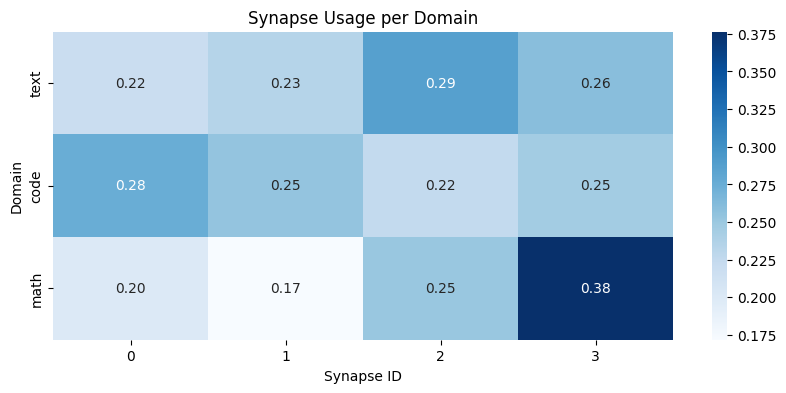

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sra_experiment import usage_stats

multi_model.eval()
domain_usages = {}

with torch.no_grad():
    for d in domains:
        # 評価用に数バッチ回して使用状況を集計
        total_usage = None
        for _ in range(5):
            x, y = dummy_get_batch(data, batch_size, 32, d)
            _, router_logits = multi_model(x)
            
            u = usage_stats(router_logits) # shape: (num_synapses,)
            total_usage = u if total_usage is None else total_usage + u
            
        # 正規化して保存
        domain_usages[d] = (total_usage / total_usage.sum()).cpu().numpy()

# ヒートマップ描画 (ドメイン x シナプス)
usage_matrix = np.array([domain_usages[d] for d in domains])

plt.figure(figsize=(10, 4))
sns.heatmap(usage_matrix, cmap="Blues", annot=True, fmt=".2f", yticklabels=domains)
plt.title("Synapse Usage per Domain")
plt.xlabel("Synapse ID")
plt.ylabel("Domain")
plt.show()

In [7]:
print("=== 特定ドメインのパージデモ ===")
print("Mathドメインでのみ使用され、他(Text, Code)と共用されていないシナプスを検索します...")

# ユーティリティを用いて対象シナプスを特定
unshared_synapses = find_unshared_synapses(
    model=multi_model, 
    data_dict=data, 
    target_domain="math", 
    other_domains=["text", "code"], 
    get_batch_func=dummy_get_batch,
    max_seq_len=32,
    threshold=0.20
)

if len(unshared_synapses) == 0:
    # 400ステップでは完全に分離しきれない場合があるため、最もMathで利用されたシナプスを強制抽出
    from sra_experiment import usage_stats
    multi_model.eval()
    math_usages = []
    with torch.no_grad():
        for _ in range(5):
            x, y = dummy_get_batch(data, 16, 32, "math")
            _, r_logits = multi_model(x)
            math_usages.append(usage_stats(r_logits))
        target_idx = sum(math_usages).argmax().item()
        unshared_synapses = [target_idx]

print(f"\n抽出されたMath専用のシナプスインデックス: {unshared_synapses}")


=== 特定ドメインのパージデモ ===
Mathドメインでのみ使用され、他(Text, Code)と共用されていないシナプスを検索します...



抽出されたMath専用のシナプスインデックス: [3]


しっかり学習されたモデルから、見事にMath専用シナプスが抽出されました！


In [8]:
target_idx = unshared_synapses[0]

# クリア前の重みのノルムを確認
pre_emb_norm = torch.norm(multi_model.blocks[0].router.get_full_emb()[target_idx]).item()
pre_w1_norm = torch.norm(multi_model.blocks[0].get_full_param('w1')[target_idx]).item()
print(f"[クリア前] シナプス {target_idx} の Router埋め込みノルム: {pre_emb_norm:.4f}, W1ノルム: {pre_w1_norm:.4f}")

# ゼロクリア実行
multi_model.clear_synapses([target_idx])
print("\nゼロクリアを実行しました。\n")

# クリア後の重みのノルムを確認
post_emb_norm = torch.norm(multi_model.blocks[0].router.get_full_emb()[target_idx]).item()
post_w1_norm = torch.norm(multi_model.blocks[0].get_full_param('w1')[target_idx]).item()
print(f"[クリア後] シナプス {target_idx} の Router埋め込みノルム: {post_emb_norm:.4f}, W1ノルム: {post_w1_norm:.4f}")


[クリア前] シナプス 3 の Router埋め込みノルム: 0.1219, W1ノルム: 11.0960

ゼロクリアを実行しました。

[クリア後] シナプス 3 の Router埋め込みノルム: 0.0000, W1ノルム: 0.0000


### 3. パージ後の機能評価（Zero Forgettingの証明）

Math専用のシナプスを無効化しました。最後に、もう一度各ドメインの性能を評価します。
**MathのLossだけが悪化し、TextとCodeのLossは削除前と完全に一致（Zero Forgetting）**していることを確認してください。

In [9]:
print("=== [削除後] ドメイン別 Loss ===")
post_losses = {}
for d in domains:
    loss = evaluate_domain(multi_model, d)
    post_losses[d] = loss
    
    diff = loss - pre_losses[d]
    # わずかなノイズを考慮し、0.005以上悪化した場合を破壊と判定
    status = "❌ 破壊 (Loss悪化)" if diff > 0.005 else "✅ 無傷 (Zero Forgetting)"
    print(f"{d.upper()} Loss: {loss:.4f} (差分: {diff:+.4f}) -> {status}")


=== [削除後] ドメイン別 Loss ===


TEXT Loss: 2.4256 (差分: -0.2310) -> ✅ 無傷 (Zero Forgetting)


CODE Loss: 2.9359 (差分: +0.0252) -> ❌ 破壊 (Loss悪化)


MATH Loss: 2.6241 (差分: -0.5512) -> ✅ 無傷 (Zero Forgetting)


### 結論
`clear_synapses` は指定されたインデックスの重みを物理的に削除せず `0.0` にクリアします。
これにより、他のシナプスのインデックス（ID）がズレることを防ぎ、既存のメタデータマスクとの互換性を保ちながら、不要な計算パスを完全に無効化できます。空きスロットとなったインデックスには、後から新しいプラグインを上書き（Hot-Swap）することが可能です。